In [1]:
# Run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

## 1. Load the data

In [2]:
DATA_URL = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'

df = pd.read_csv(DATA_URL)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Quick data dictionary

| Column | Meaning |
|---|---|
| `age` | Age of primary beneficiary |
| `sex` | Sex |
| `bmi` | Body mass index |
| `children` | Number of covered children |
| `smoker` | Smoking status |
| `region` | Residential region in the US |
| `charges` | Individual medical costs billed by insurance — **target** |

In [3]:
print('Shape:', df.shape)
display(df.info())
display(df.describe(include='all').T)
display(df.isna().sum())
print('Duplicate rows:', df.duplicated().sum())
answer_1 = 'Target: charges. Categorical: sex, smoker, region.'

Shape: (1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1


## 2. Exploratory analysis

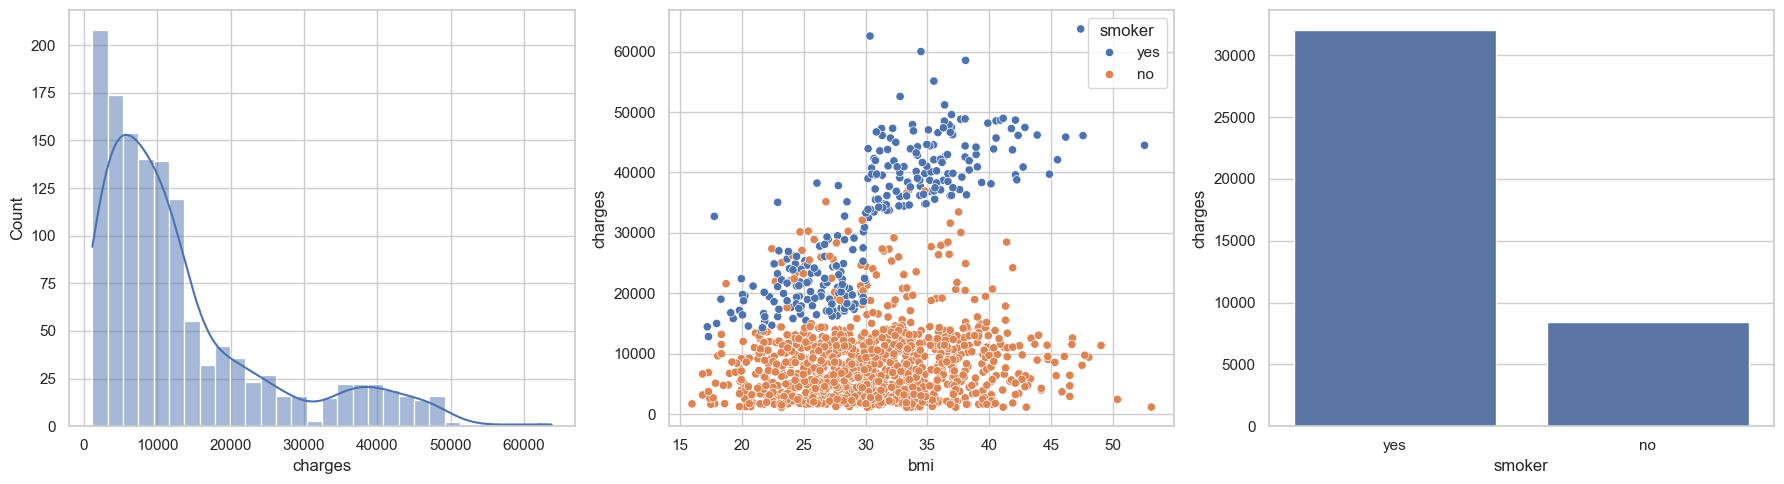

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A
sns.histplot(data=df, x='charges', kde=True, ax=axes[0])

# Plot B
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1])

# Plot C
sns.barplot(data=df, x='smoker', y='charges', estimator='mean', errorbar=None, ax=axes[2])

plt.tight_layout()
plt.show()

In [5]:
observations = [
    'Charges are strongly right-skewed.',
    'Smokers generally have much higher charges.',
    'The BMI–charges relationship differs by smoking status.'
]
observations

['Charges are strongly right-skewed.',
 'Smokers generally have much higher charges.',
 'The BMI–charges relationship differs by smoking status.']

## 3. Feature engineering

Create features that may help a linear model describe nonlinear or interaction effects:

- `bmi_squared = bmi²`
- `age_squared = age²`
- `age_bmi = age × bmi`
- `smoker_bmi`: interaction between smoker status and BMI
- `bmi_category`: Underweight / Normal / Overweight / Obese

Think first: why might smoker × BMI be more useful than either column alone?

In [6]:
model_df = df.copy()
model_df['bmi_squared'] = model_df['bmi'] ** 2
model_df['age_squared'] = model_df['age'] ** 2
model_df['age_bmi'] = model_df['age'] * model_df['bmi']
model_df['smoker_bmi'] = (model_df['smoker'] == 'yes').astype(int) * model_df['bmi']
model_df['bmi_category'] = pd.cut(
    model_df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

model_df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_squared,age_squared,age_bmi,smoker_bmi,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,778.410000,361,530.100,27.9,Overweight
1,18,male,33.770,1,no,southeast,1725.55230,1140.412900,324,607.860,0.0,Obese
2,28,male,33.000,3,no,southeast,4449.46200,1089.000000,784,924.000,0.0,Obese
3,33,male,22.705,0,no,northwest,21984.47061,515.517025,1089,749.265,0.0,Normal
4,32,male,28.880,0,no,northwest,3866.85520,834.054400,1024,924.160,0.0,Overweight


## 4. Train/test split — do this before fitting preprocessing

In [7]:
X = model_df.drop(columns='charges')
y = model_df['charges']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
print(X_train.shape, X_test.shape)

(1070, 11) (268, 11)


In [8]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Numeric:', numeric_features)
print('Categorical:', categorical_features)

Numeric: ['age', 'bmi', 'children', 'bmi_squared', 'age_squared', 'age_bmi', 'smoker_bmi']
Categorical: ['sex', 'smoker', 'region', 'bmi_category']


## 6. Evaluation helper

In [9]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    return {
        'Model': name,
        'Train R2': r2_score(y_train, train_pred),
        'Test R2': r2_score(y_test, test_pred),
        'Train RMSE': mean_squared_error(y_train, train_pred) ** 0.5,
        'Test RMSE': mean_squared_error(y_test, test_pred) ** 0.5,
        'Test MAE': mean_absolute_error(y_test, test_pred),
        'R2 Gap': r2_score(y_train, train_pred) - r2_score(y_test, test_pred)
    }

## 7. Baseline: deliberately simple model

In [10]:
simple_model = Pipeline(steps=[
    ('preprocessor', ColumnTransformer([
        ('age', StandardScaler(), ['age'])
    ], remainder='drop')),
    ('model', LinearRegression())
])

results = []
results.append(evaluate_model('Age-only Linear', simple_model, X_train, X_test, y_train, y_test))
pd.DataFrame(results)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE,R2 Gap
0,Age-only Linear,0.079367,0.12409,11527.28721,11661.215952,9173.258197,-0.044723


In [11]:
underfitting_explanation = 'The age-only model has low R² on both train and test sets, so it misses important patterns.'

## 8. Linear regression with all prepared features

In [12]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

results.append(evaluate_model('Full Linear', linear_model, X_train, X_test, y_train, y_test))
pd.DataFrame(results).round(3)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE,R2 Gap
0,Age-only Linear,0.079,0.124,11527.287,11661.216,9173.258,-0.045
1,Full Linear,0.844,0.871,4750.065,4479.822,2668.170,-0.027


## 9. Polynomial regression: model complexity experiment

To make the bias–variance pattern visible, use only `age` and `bmi`, then test degrees **1, 2, 3, 5, and 8**. Polynomial features can grow very quickly.

In [13]:
poly_results = []

for degree in [1, 2, 3, 5, 8]:
    poly_model = Pipeline(steps=[
        ('select_scale', ColumnTransformer([
            ('num', StandardScaler(), ['age', 'bmi'])
        ], remainder='drop')),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('model', LinearRegression())
    ])
    poly_results.append(evaluate_model(f'Polynomial d={degree}', poly_model, X_train, X_test, y_train, y_test))

poly_df = pd.DataFrame(poly_results)
poly_df.round(3)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE,R2 Gap
0,Polynomial d=1,0.107,0.153,11355.239,11464.740,9222.665,-0.047
1,Polynomial d=2,0.110,0.145,11335.159,11519.096,9214.983,-0.036
2,Polynomial d=3,0.116,0.126,11295.996,11646.152,9307.701,-0.010
3,Polynomial d=5,0.124,0.123,11245.470,11671.505,9276.502,0.001
4,Polynomial d=8,0.147,-0.143,11097.741,13319.566,9661.876,0.289


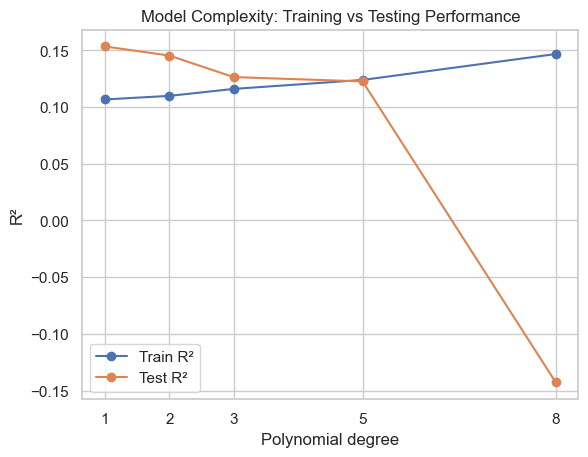

In [14]:
poly_df['Degree'] = poly_df['Model'].str.extract(r'(\d+)$').astype(int)

plt.plot(poly_df['Degree'], poly_df['Train R2'], marker='o', label='Train R²')
plt.plot(poly_df['Degree'], poly_df['Test R2'], marker='o', label='Test R²')
plt.xlabel('Polynomial degree')
plt.ylabel('R²')
plt.title('Model Complexity: Training vs Testing Performance')
plt.xticks(poly_df['Degree'])
plt.legend()
plt.show()

In [15]:
complexity_conclusion = '''
Underfitting: Degree 1 if both train and test R² are low.
Best generalization: Choose the degree with the strongest test R² / lowest test RMSE and a small gap.
Overfitting: The high degree with a strong train score but weaker test score.
Evidence: Compare Train R², Test R², RMSE, and the R² gap in your executed output.
'''
print(complexity_conclusion)


Underfitting: Degree 1 if both train and test R² are low.
Best generalization: Choose the degree with the strongest test R² / lowest test RMSE and a small gap.
Overfitting: The high degree with a strong train score but weaker test score.
Evidence: Compare Train R², Test R², RMSE, and the R² gap in your executed output.



## 10. Ridge and Lasso regularization

In [16]:
regularization_results = []

for alpha in [0.01, 0.1, 1, 10, 100]:
    ridge_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])
    regularization_results.append(evaluate_model(f'Ridge α={alpha}', ridge_model, X_train, X_test, y_train, y_test))

    lasso_model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=alpha, max_iter=20000))
    ])
    regularization_results.append(evaluate_model(f'Lasso α={alpha}', lasso_model, X_train, X_test, y_train, y_test))

reg_df = pd.DataFrame(regularization_results)
reg_df.sort_values('Test RMSE').round(3)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE,R2 Gap
4,Ridge α=1,0.843,0.871,4754.298,4475.408,2661.759,-0.028
2,Ridge α=0.1,0.844,0.871,4750.116,4478.976,2666.893,-0.027
7,Lasso α=10,0.843,0.871,4757.298,4479.388,2663.999,-0.028
0,Ridge α=0.01,0.844,0.871,4750.065,4479.733,2668.039,-0.027
1,Lasso α=0.01,0.844,0.871,4750.065,4479.837,2668.122,-0.027
3,Lasso α=0.1,0.844,0.871,4750.067,4480.017,2667.718,-0.027
5,Lasso α=1,0.844,0.871,4750.225,4481.512,2664.279,-0.027
6,Ridge α=10,0.835,0.866,4875.988,4560.472,2804.075,-0.031
9,Lasso α=100,0.821,0.855,5076.397,4750.340,3010.557,-0.033
8,Ridge α=100,0.811,0.845,5228.237,4899.059,3356.250,-0.035


## 11. Final comparison and reflection

Complete the table and answer the questions using evidence from your outputs.

In [17]:
all_results = pd.concat([
    pd.DataFrame(results),
    poly_df.drop(columns='Degree'),
    reg_df
], ignore_index=True)

all_results.sort_values('Test RMSE').head(10).round(3)

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Test MAE,R2 Gap
11,Ridge α=1,0.843,0.871,4754.298,4475.408,2661.759,-0.028
9,Ridge α=0.1,0.844,0.871,4750.116,4478.976,2666.893,-0.027
14,Lasso α=10,0.843,0.871,4757.298,4479.388,2663.999,-0.028
7,Ridge α=0.01,0.844,0.871,4750.065,4479.733,2668.039,-0.027
1,Full Linear,0.844,0.871,4750.065,4479.822,2668.170,-0.027
8,Lasso α=0.01,0.844,0.871,4750.065,4479.837,2668.122,-0.027
10,Lasso α=0.1,0.844,0.871,4750.067,4480.017,2667.718,-0.027
12,Lasso α=1,0.844,0.871,4750.225,4481.512,2664.279,-0.027
13,Ridge α=10,0.835,0.866,4875.988,4560.472,2804.075,-0.031
16,Lasso α=100,0.821,0.855,5076.397,4750.340,3010.557,-0.033


In [18]:
final_answers = {
    '1. Which model generalized best, and what evidence supports that?': 'The model with the lowest test RMSE and a small train-test R² gap.',
    '2. Which model underfit? How can you tell?': 'The age-only model: low performance on both training and testing data.',
    '3. Which model overfit? How can you tell?': 'The highest-degree polynomial when training improves but testing degrades.',
    '4. What happened as alpha increased?': 'Coefficients shrank; variance may fall, but excessive alpha raises bias and can underfit.',
    '5. Why must preprocessing be fitted on training data only?': 'Fitting on all data leaks information from the test set and makes evaluation optimistic.',
    '6. Which engineered feature seems most meaningful, and why?': 'smoker_bmi, because the visuals suggest BMI has a different relationship with charges for smokers.'
}
final_answers

{'1. Which model generalized best, and what evidence supports that?': 'The model with the lowest test RMSE and a small train-test R² gap.',
 '2. Which model underfit? How can you tell?': 'The age-only model: low performance on both training and testing data.',
 '3. Which model overfit? How can you tell?': 'The highest-degree polynomial when training improves but testing degrades.',
 '4. What happened as alpha increased?': 'Coefficients shrank; variance may fall, but excessive alpha raises bias and can underfit.',
 '5. Why must preprocessing be fitted on training data only?': 'Fitting on all data leaks information from the test set and makes evaluation optimistic.',
 '6. Which engineered feature seems most meaningful, and why?': 'smoker_bmi, because the visuals suggest BMI has a different relationship with charges for smokers.'}